# Basic Neural Networks

Tutorial of Computational Linguistics, National Chengchi University

*Chang-Yu Tsai, 2025.03.28*

- In this week, we will try:
  - to understand the concept of activation functions
  - to understand the concept of `epoch`
  - to visualise the loss curve to investigate the model generalisation


## Set-up

- importing required packages

```
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import numpy as np

import re
```


In [ ]:
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import numpy as np

import re

## Preprocessing

- downloading the dataset from github
> Our data was collected from Cofacts. If you want to explore more on their dataset, please refer to [this website](https://huggingface.co/datasets/Cofacts/line-msg-fact-check-tw).

```
!wget https://raw.githubusercontent.com/EntropiaTsai/nccu_elt_course_material/refs/heads/main/balanced_misinformation.csv
```

In [ ]:
!wget https://raw.githubusercontent.com/EntropiaTsai/nccu_elt_course_material/refs/heads/main/balanced_misinformation.csv

--2025-03-28 03:15:58--  https://raw.githubusercontent.com/EntropiaTsai/nccu_elt_course_material/refs/heads/main/balanced_misinformation.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 18379337 (18M) [text/plain]
Saving to: ‘balanced_misinformation.csv’

balanced_misinforma 100%[===================>]  17.53M  --.-KB/s    in 0.1s    

2025-03-28 03:15:58 (180 MB/s) - ‘balanced_misinformation.csv’ saved [18379337/18379337]



- reading the file

```
df = pd.read_csv('balanced_misinformation.csv',encoding='utf-8')
print('The dataframe contains', len(df), 'rows.')
df.head()
```

In [ ]:
df = pd.read_csv('balanced_misinformation.csv',encoding='utf-8')
print('The dataframe contains', len(df), 'rows.')
df.head()

The dataframe contains 25170 rows.


,text,title,type
0,https://tw.news.yahoo.com/%E6%A0%B8%E5%BB%A2%E...,政治,OPINIONATED
1,"昨天6/15時鐘說,政府買進居\n家快篩劑一份一千元,需要的\n民眾可以洽購。\n今天6/1...",法律,RUMOR
2,桃園市議會 通過112年度預算 明年起即可全面適用\n☝️自111學年度下學期起，全面推動...,法律,NOT_RUMOR
3,救命藥出現了？ 美治療首例確診病患 1天後退燒 實驗藥奏效\n\n世界日報\n2020/02...,健康醫療,RUMOR
4,一月初我被幾個中國醫生朋友拉入中國人所成立的幫助武漢群組WeChat裡面，我在裡面什麼都沒幹...,政治,OPINIONATED


- extracting features

```
# searching the key words of links
links=[]
for text in df['text']:
  if re.search('http',text):
    result=1
  else:
    result=0
  links.append(result)

df['links']=links

# taking a look at the current dataframe
df.head()
```

In [ ]:
# searching the key words of links
links=[]
for text in df['text']:
  if re.search('http',text):
    result=1
  else:
    result=0
  links.append(result)

df['links']=links

# taking a look at the current dataframe
df.head()

,text,title,type,links
0,https://tw.news.yahoo.com/%E6%A0%B8%E5%BB%A2%E...,政治,OPINIONATED,1
1,"昨天6/15時鐘說,政府買進居\n家快篩劑一份一千元,需要的\n民眾可以洽購。\n今天6/1...",法律,RUMOR,0
2,桃園市議會 通過112年度預算 明年起即可全面適用\n☝️自111學年度下學期起，全面推動...,法律,NOT_RUMOR,0
3,救命藥出現了？ 美治療首例確診病患 1天後退燒 實驗藥奏效\n\n世界日報\n2020/02...,健康醫療,RUMOR,1
4,一月初我被幾個中國醫生朋友拉入中國人所成立的幫助武漢群組WeChat裡面，我在裡面什麼都沒幹...,政治,OPINIONATED,0


- encoding data
  - We need to encode contents that cannot be understood by the model. `LabelEncoder()` is one of the common approaches.

```
# converting features
features_label_encoder = LabelEncoder()
df["title_encoded"] = features_label_encoder.fit_transform(df["title"])
# converting labels
labels_label_encoder = LabelEncoder()
df["type_encoded"] = labels_label_encoder.fit_transform(df["type"])
df.head()
```

In [ ]:
# converting features
features_label_encoder = LabelEncoder()
df["title_encoded"] = features_label_encoder.fit_transform(df["title"])
# converting labels
labels_label_encoder = LabelEncoder()
df["type_encoded"] = labels_label_encoder.fit_transform(df["type"])
df.head()

,text,title,type,links,title_encoded,type_encoded
0,https://tw.news.yahoo.com/%E6%A0%B8%E5%BB%A2%E...,政治,OPINIONATED,1,5,1
1,"昨天6/15時鐘說,政府買進居\n家快篩劑一份一千元,需要的\n民眾可以洽購。\n今天6/1...",法律,RUMOR,0,6,2
2,桃園市議會 通過112年度預算 明年起即可全面適用\n☝️自111學年度下學期起，全面推動...,法律,NOT_RUMOR,0,6,0
3,救命藥出現了？ 美治療首例確診病患 1天後退燒 實驗藥奏效\n\n世界日報\n2020/02...,健康醫療,RUMOR,1,1,2
4,一月初我被幾個中國醫生朋友拉入中國人所成立的幫助武漢群組WeChat裡面，我在裡面什麼都沒幹...,政治,OPINIONATED,0,5,1


- seperating the features and labels

```
features=df[['title_encoded','links']]
labels=df['type_encoded']
print('Feature:')
features.head()
# print('Labels:')
# labels.head()
```

In [ ]:
features=df[['title_encoded','links']]
labels=df['type_encoded']
print('Feature:')
features.head()
# print('Labels:')
# labels.head()

Feature:


,title_encoded,links
0,5,1
1,6,0
2,6,0
3,1,1
4,5,0


- splitting the training set, the dev set, and the test set

```
# shuffling the dataframe
df_shuffled = df.sample(frac=1, random_state=42)

# defining how to split the data into training, dev, and test sets
n_total = len(df)
n_train = int(0.7 * n_total)
n_dev   = int(0.1 * n_total)

# splitting with `np.split`
df_train, df_dev, df_test = np.split(df_shuffled, [n_train, n_train + n_dev])

```

In [1]:
# shuffling the dataframe
df_shuffled = df.sample(frac=1, random_state=42)

# defining how to split the data into training, dev, and test sets
n_total = len(df)
n_train = int(0.7 * n_total)
n_dev   = int(0.1 * n_total)

# splitting with `np.split`
df_train, df_dev, df_test = np.split(df_shuffled, [n_train, n_train + n_dev])

NameError: name 'df' is not defined

- Converting features and labels into tensors


```
# splitting features and label of the training set
feat_train = df_train.drop(columns=['type_encoded','text','title','type'])
label_train = df_train['type_encoded']

# splitting features and label of the dev set
feat_dev = df_dev.drop(columns=['type_encoded','text','title','type'])
label_dev = df_dev['type_encoded']

# splitting features and label of the test set
feat_test = df_test.drop(columns=['type_encoded','text','title','type'])
label_test = df_test['type_encoded']

# inspecting the results
feat_train
# label_train
```

In [ ]:
# splitting features and label of the training set
feat_train = df_train.drop(columns=['type_encoded','text','title','type'])
label_train = df_train['type_encoded']

# splitting features and label of the dev set
feat_dev = df_dev.drop(columns=['type_encoded','text','title','type'])
label_dev = df_dev['type_encoded']

# splitting features and label of the test set
feat_test = df_test.drop(columns=['type_encoded','text','title','type'])
label_test = df_test['type_encoded']

# inspecting the results
feat_train
# label_train

,links,title_encoded
23451,1,2
6434,0,5
16183,0,1
7339,0,2
20846,1,2
...,...,...
24273,1,1
16696,0,2
2073,0,5
9730,1,2


- converting data into `TensorDataset`

```
feat_train_tensor = torch.tensor(feat_train.values, dtype=torch.float32)
label_train_tensor = torch.tensor(label_train.values, dtype=torch.long)

feat_dev_tensor = torch.tensor(feat_dev.values, dtype=torch.float32)
label_dev_tensor = torch.tensor(label_dev.values, dtype=torch.long)

feat_test_tensor = torch.tensor(feat_test.values, dtype=torch.float32)
label_test_tensor = torch.tensor(label_test.values, dtype=torch.long)

# converting `TensorDataset`
dataset_train = TensorDataset(feat_train_tensor, label_train_tensor)
dataset_dev = TensorDataset(feat_dev_tensor, label_dev_tensor)
dataset_test = TensorDataset(feat_test_tensor, label_test_tensor)
```

In [ ]:
feat_train_tensor = torch.tensor(feat_train.values, dtype=torch.float32)
label_train_tensor = torch.tensor(label_train.values, dtype=torch.long)

feat_dev_tensor = torch.tensor(feat_dev.values, dtype=torch.float32)
label_dev_tensor = torch.tensor(label_dev.values, dtype=torch.long)

feat_test_tensor = torch.tensor(feat_test.values, dtype=torch.float32)
label_test_tensor = torch.tensor(label_test.values, dtype=torch.long)

# converting `TensorDataset`
dataset_train = TensorDataset(feat_train_tensor, label_train_tensor)
dataset_dev = TensorDataset(feat_dev_tensor, label_dev_tensor)
dataset_test = TensorDataset(feat_test_tensor, label_test_tensor)

- creating datasets for mini-batch training

```
# setting  batch size
batch_size = 32

# converting `TensorDataset` into `DataLoader` for mini-batch training
train_loader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
dev_loader = DataLoader(dataset_dev, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset_test, batch_size=batch_size, shuffle=False)
```

In [ ]:
# setting  batch size
batch_size = 32

# converting `TensorDataset` into `DataLoader` for mini-batch training
train_loader = DataLoader(dataset_train, batch_size=batch_size, shuffle=True)
dev_loader = DataLoader(dataset_dev, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset_test, batch_size=batch_size, shuffle=False)

## Model Training

We are now building a basic neural network model with:
- one fully connected layer serving as the hidden (intermediate) layer
- one activation function, `ReLU()`, applied after the hidden layer
- one fully connected output layer that maps to the number of label classes (i.e., outputs the logits)

> These logits are later converted into label probabilities through the internal `Softmax` computation within `nn.CrossEntropyLoss()` during training.

```
class BasicNeuralNetworks(nn.Module):
    def __init__(self, input_dim, num_classes, hidden_dim=256):
        super().__init__()
        self.input_layer = nn.Linear(input_dim, hidden_dim)
        self.hidden_layer = nn.Linear(hidden_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.output_layer = nn.Linear(hidden_dim,num_classes)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.hidden_layer(x)
        x = self.relu(x)
        x = self.output_layer(x)
        return x
```

In [ ]:
class BasicNeuralNetworks(nn.Module):
    def __init__(self, input_dim, num_classes, hidden_dim=256):
        super().__init__()
        self.input_layer = nn.Linear(input_dim, hidden_dim)
        self.hidden_layer = nn.Linear(hidden_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.output_layer = nn.Linear(hidden_dim,num_classes)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.hidden_layer(x)
        x = self.relu(x)
        x = self.output_layer(x)
        return x

- initialising the model

```
torch.manual_seed(4) # the random seed of initialisation
model = BasicNeuralNetworks(input_dim=feat_train_tensor.shape[1],
                            num_classes=len(torch.unique(label_train_tensor)))

# setting the loss function
criterion = nn.CrossEntropyLoss()

# setting up the optimiser
learning_rate = 0.001
l2_lambda = 0.001

optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=l2_lambda
)
```

In [ ]:
torch.manual_seed(4) # the random seed of initialisation
model = BasicNeuralNetworks(input_dim=feat_train_tensor.shape[1],
                            num_classes=len(torch.unique(label_train_tensor)))

# setting the loss function
criterion = nn.CrossEntropyLoss()

# setting up the optimiser
learning_rate = 0.001
l2_lambda = 0.001

optimizer = optim.Adam(
    model.parameters(),
    lr=learning_rate,
    weight_decay=l2_lambda
)

- training the Model

After setting up the relevant parameters (i.e., batch size and learning rate), we now train the model for 30 epochs.

> We can evaluate the model’s generalization ability by observing the loss trends during training. A common approach is to compare the loss trends of the dev set and the training set.


```
num_epochs = 30
train_losses = []
dev_losses = []

for epoch in range(num_epochs):
    model.train()  # starting training
    train_loss = 0.0

    for batch_feat, batch_label in train_loader:
        batch_feat = batch_feat.float()
        batch_label = batch_label.long()

        optimizer.zero_grad()
        predictions = model(batch_feat)
        loss = criterion(predictions, batch_label)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * batch_feat.size(0)  # accumulating the loss of each mini-batch

    avg_train_loss = train_loss / len(train_loader.dataset)

    # validation phase
    model.eval()  # starting evaluating on the dev set
    dev_loss = 0.0

    with torch.no_grad():  # pausing calculating the gradient
        for batch_feat, batch_label in dev_loader:
            batch_feat = batch_feat.float()
            batch_label = batch_label.long()
            predictions = model(batch_feat)
            loss = criterion(predictions, batch_label)
            dev_loss += loss.item() * batch_feat.size(0)

    avg_dev_loss = dev_loss / len(dev_loader.dataset)

    # saving the value the loss of each epoch
    train_losses.append(avg_train_loss)
    dev_losses.append(avg_dev_loss)

    # printing the loss of each epoch
    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {avg_train_loss:.4f} - Dev Loss: {avg_dev_loss:.4f}")

```

In [ ]:
num_epochs = 30
train_losses = []
dev_losses = []

for epoch in range(num_epochs):
    model.train()  # starting training
    train_loss = 0.0

    for batch_feat, batch_label in train_loader:
        batch_feat = batch_feat.float()
        batch_label = batch_label.long()

        optimizer.zero_grad()
        predictions = model(batch_feat)
        loss = criterion(predictions, batch_label)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * batch_feat.size(0)  # accumulating the loss of each mini-batch

    avg_train_loss = train_loss / len(train_loader.dataset)

    # validation phase
    model.eval()  # starting evaluating on the dev set
    dev_loss = 0.0

    with torch.no_grad():  # pausing calculating the gradient
        for batch_feat, batch_label in dev_loader:
            batch_feat = batch_feat.float()
            batch_label = batch_label.long()
            predictions = model(batch_feat)
            loss = criterion(predictions, batch_label)
            dev_loss += loss.item() * batch_feat.size(0)

    avg_dev_loss = dev_loss / len(dev_loader.dataset)

    # saving the value the loss of each epoch
    train_losses.append(avg_train_loss)
    dev_losses.append(avg_dev_loss)

    # printing the loss of each epoch
    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {avg_train_loss:.4f} - Dev Loss: {avg_dev_loss:.4f}")

Epoch 1/30 - Train Loss: 1.0869 - Dev Loss: 1.0794
Epoch 2/30 - Train Loss: 1.0762 - Dev Loss: 1.0722
Epoch 3/30 - Train Loss: 1.0746 - Dev Loss: 1.0732
Epoch 4/30 - Train Loss: 1.0734 - Dev Loss: 1.0693
Epoch 5/30 - Train Loss: 1.0732 - Dev Loss: 1.0688
Epoch 6/30 - Train Loss: 1.0723 - Dev Loss: 1.0708
Epoch 7/30 - Train Loss: 1.0719 - Dev Loss: 1.0688
Epoch 8/30 - Train Loss: 1.0710 - Dev Loss: 1.0683
Epoch 9/30 - Train Loss: 1.0697 - Dev Loss: 1.0698
Epoch 10/30 - Train Loss: 1.0698 - Dev Loss: 1.0690
Epoch 11/30 - Train Loss: 1.0694 - Dev Loss: 1.0661
Epoch 12/30 - Train Loss: 1.0692 - Dev Loss: 1.0706
Epoch 13/30 - Train Loss: 1.0687 - Dev Loss: 1.0653
Epoch 14/30 - Train Loss: 1.0681 - Dev Loss: 1.0690
Epoch 15/30 - Train Loss: 1.0662 - Dev Loss: 1.0665
Epoch 16/30 - Train Loss: 1.0644 - Dev Loss: 1.0610
Epoch 17/30 - Train Loss: 1.0617 - Dev Loss: 1.0581
Epoch 18/30 - Train Loss: 1.0596 - Dev Loss: 1.0577
Epoch 19/30 - Train Loss: 1.0586 - Dev Loss: 1.0576
Epoch 20/30 - Train L

- Plotting the Loss Curve  
> Observe the trend of the loss curves, and consider the following questions:  
> 1. Do the training and dev loss curves show a similar trend?  
> 2. Why is the dev loss higher than the training loss in some epochs?
> **Hint:** You can also describe whether the model might be underfitting, overfitting, or learning properly based on the shape of the curves.

```
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Training Loss")
plt.plot(dev_losses, label="Dev Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Dev Loss over Epochs")
plt.legend()
plt.grid(True)
plt.show()
```

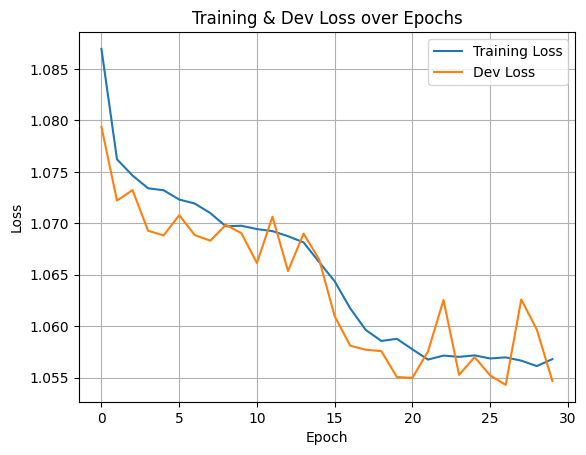

In [ ]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Training Loss")
plt.plot(dev_losses, label="Dev Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Dev Loss over Epochs")
plt.legend()
plt.grid(True)
plt.show()

## Predicting and evaluating


```
# prediciting
model.eval()
label_true = []
label_pred = []

with torch.no_grad():
    for batch_feat, batch_label in test_loader:
        batch_feat = batch_feat.float()
        batch_label = batch_label.long()
        test_predictions = model(batch_feat)

        predicted_labels = torch.argmax(test_predictions, dim=1)

        label_true.extend(batch_label.cpu().numpy())
        label_pred.extend(predicted_labels.cpu().numpy())
# evaluating
accuracy = accuracy_score(label_true, label_pred)
precision = precision_score(label_true, label_pred, average='weighted')
recall = recall_score(label_true, label_pred, average='weighted')
f1 = f1_score(label_true, label_pred, average='weighted')

# printing out the results
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")
```


In [ ]:
# prediciting
model.eval()
label_true = []
label_pred = []

with torch.no_grad():
    for batch_feat, batch_label in test_loader:
        batch_feat = batch_feat.float()
        batch_label = batch_label.long()
        test_predictions = model(batch_feat)

        predicted_labels = torch.argmax(test_predictions, dim=1)

        label_true.extend(batch_label.cpu().numpy())
        label_pred.extend(predicted_labels.cpu().numpy())
# evaluating
accuracy = accuracy_score(label_true, label_pred)
precision = precision_score(label_true, label_pred, average='weighted')
recall = recall_score(label_true, label_pred, average='weighted')
f1 = f1_score(label_true, label_pred, average='weighted')

# printing out the results
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1 Score: {f1:.4f}")

Test Accuracy: 0.4766
Precision: 0.4940, Recall: 0.4766, F1 Score: 0.4663


# Assignment

Please create a new `.ipynb` file to complete your assignment. Don't forget to include your name and relevant information at the top of your code.


1. Basic Neurak Networks

  - Add more than two features. You may also use pre-trained embeddings such as `word2vec`. Explain your reasoning for the additional features. (10\%)

  - In class, we used 128 as the hidden dimension. Now, try adjusting the dimension and compare the results. (20\%)

  -  Change the activation function of the model. Explain how it differs from `ReLU()`. (20\%)

2. Loss curve and generalisation
  - Choose your own batch size and learning rate. Train your model for more than 30 epochs using these settings. (20\%)

  - Plot the loss trends for both the training and dev sets, and analyse what they reveal about the model’s generalization ability. (20\%)

**Bonus:** Make the model more complex by adding additional hidden layers.
You can add as many layers as you like, but make sure to clearly specify the dimensions between layers to avoid shape mismatch errors.